# 03 · Threshold selection and business-cost analysis

A model outputs a **score**. The fraud team needs a **decision**: alert or don't alert. The threshold is a business decision that trades missed fraud against analyst time. This notebook makes that trade-off explicit, in dollars and in alerts per analyst per day.

**Protocol.** Thresholds are **chosen on validation** and **confirmed on test** without changing them.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config, costs, metrics, plotting
from src.plotting import takeaway

plotting.set_style()
pd.set_option("display.width", 200, "display.max_columns", 30, "display.float_format", "{:,.4f}".format)

scores = pd.read_parquet(config.DATA_PROCESSED / "scores.parquet")
va, te = scores[scores.split == "validation"].reset_index(drop=True), scores[scores.split == "test"].reset_index(drop=True)
DAYS = {"validation": metrics.n_days(va.ts), "test": metrics.n_days(te.ts)}
MODEL = "score_LightGBM"
meta = json.loads((config.REPORTS / "model_metadata.json").read_text())
DAYS

{'validation': 140, 'test': 129}

## 1. Cost framework and assumptions

$$\text{Total cost} = \underbrace{\sum_{\text{missed frauds}} \text{amount}\times(1-\text{recovery})}_{\text{fraud loss (FN)}} + \underbrace{(\text{TP}+\text{FP})\times\text{review cost}}_{\text{analyst cost}}$$

There are two variants:
- **FP-only:** `FN x loss + FP x review cost`. This is the textbook version, where only false alerts count as waste.
- **All alerts (primary):** `FN x loss + (TP + FP) x review cost`. **This is the one we use.** An analyst has to open every alert, including the real frauds, so every alert costs time. The FP-only version understates the cost of alerting and pushes towards lower thresholds.

**Assumption: an alerted fraud is stopped.** The score is used at authorisation to hold the transaction for review, so a caught fraud costs only the review. If the queue were worked after authorisation, some caught fraud would still be lost. The sensitivity analysis (±50% loss) covers part of that uncertainty.

In [2]:
assumptions = pd.DataFrame([
    ("Fraud loss per missed fraud", "Transaction amount x (1 - recovery rate)", "Direct loss; the amount is available per transaction, so no flat average is needed"),
    ("Chargeback / recovery rate", f"{config.RECOVERY_RATE:.0%}", "Conservative: assume nothing is recovered. Partial recovery is covered by the -50% loss sensitivity"),
    ("Review cost per alert", f"${config.REVIEW_COST:.2f}", "~8 minutes of analyst time at a ~$40/hour fully loaded cost"),
    ("Analysts", f"{config.N_ANALYSTS}", "Small fraud-ops team sized to this portfolio (~2,500-2,900 transactions/day)"),
    ("Reviews per analyst per day", f"{config.REVIEWS_PER_ANALYST_PER_DAY}", "~8 minutes each over a ~7-hour working day, with time left for escalations"),
    ("Daily review capacity", f"{config.DAILY_REVIEW_CAPACITY} alerts/day", "Analysts x reviews per analyst"),
    ("Recall target", f"{config.RECALL_TARGET:.0%}", "Example of a policy-driven target (e.g. a risk-appetite statement)"),
    ("Cost variant used", "All alerts (TP + FP) incur the review cost", "Analysts review every alert, not only the false ones"),
], columns=["assumption", "value", "rationale"])
assumptions.to_csv(config.REPORTS / "assumptions.csv", index=False)
assumptions

,assumption,value,rationale
0,Fraud loss per missed fraud,Transaction amount x (1 - recovery rate),Direct loss; the amount is available per trans...
1,Chargeback / recovery rate,0%,Conservative: assume nothing is recovered. Par...
2,Review cost per alert,$5.00,~8 minutes of analyst time at a ~$40/hour full...
3,Analysts,2,Small fraud-ops team sized to this portfolio (...
4,Reviews per analyst per day,50,"~8 minutes each over a ~7-hour working day, wi..."
5,Daily review capacity,100 alerts/day,Analysts x reviews per analyst
6,Recall target,80%,Example of a policy-driven target (e.g. a risk...
7,Cost variant used,All alerts (TP + FP) incur the review cost,"Analysts review every alert, not only the fals..."


## 2. Threshold sweep on validation

The sweep evaluates about 4,000 candidate thresholds (quantiles of the score, with extra resolution in the top 5% where operating points live). The cost-optimal point sits where one more alert costs more in review time than the fraud it is expected to catch.

In [3]:
grid_va = costs.threshold_grid(va[MODEL])
sweep_va = costs.sweep(va.is_fraud, va[MODEL], va.amt, DAYS["validation"], grid_va)
opt_cost = costs.cost_minimising(sweep_va)
opt_cap = costs.capacity_constrained(sweep_va)
opt_rec = costs.recall_target(sweep_va)
options = {"Cost-minimising": opt_cost, "Capacity-constrained (fill 100/day)": opt_cap, f"Recall target ({config.RECALL_TARGET:.0%})": opt_rec}
thr = {k: float(v.threshold) for k, v in options.items()}
show = ["threshold", "alerts_per_day", "TP", "FP", "FN", "precision", "recall", "fraud_caught_usd", "fraud_missed_usd",
        "review_cost_all_alerts_usd", "total_cost_usd"]
opt_va = pd.DataFrame(options).T[show]
opt_va

,threshold,alerts_per_day,TP,FP,FN,precision,recall,fraud_caught_usd,fraud_missed_usd,review_cost_all_alerts_usd,total_cost_usd
Cost-minimising,0.0084,21.2071,"1,871.0000","1,098.0000",36.0000,0.6302,0.9811,"985,998.4700","4,993.8000","14,845.0000","19,838.8000"
Capacity-constrained (fill 100/day),0.0002,99.9786,"1,904.0000","12,093.0000",3.0000,0.1360,0.9984,"990,958.7400",33.5300,"69,985.0000","70,018.5300"
Recall target (80%),0.8889,11.0000,"1,528.0000",12.0000,379.0000,0.9922,0.8013,"840,603.0400","150,389.2300","7,700.0000","158,089.2300"


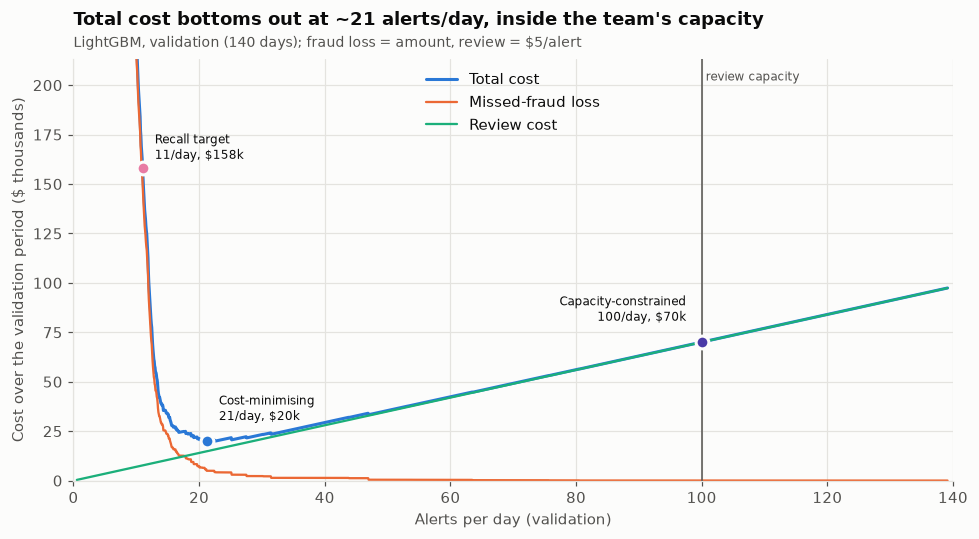

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
s = sweep_va[(sweep_va.alerts_per_day > 0.5) & (sweep_va.alerts_per_day <= 140)]
ax.plot(s.alerts_per_day, s.total_cost_usd / 1e3, color=plotting.BLUE, label="Total cost")
ax.plot(s.alerts_per_day, s.expected_fraud_loss_usd / 1e3, color=plotting.ORANGE, lw=1.5, label="Missed-fraud loss")
ax.plot(s.alerts_per_day, s.review_cost_all_alerts_usd / 1e3, color=plotting.AQUA, lw=1.5, label="Review cost")
ax.axvline(config.DAILY_REVIEW_CAPACITY, color=plotting.TEXT_2, lw=1)
ax.text(config.DAILY_REVIEW_CAPACITY, 0.97, " review capacity", color=plotting.TEXT_2, fontsize=8, va="top",
        transform=ax.get_xaxis_transform())
for (name, row), col, off in zip(options.items(), [plotting.BLUE, plotting.VIOLET, plotting.MAGENTA], [(8, 14), (-10, 14), (8, 6)]):
    ax.scatter(row.alerts_per_day, row.total_cost_usd / 1e3, s=70, color=col, zorder=4, edgecolor=plotting.SURFACE, linewidth=2)
    ax.annotate(f"{name.split(' (')[0]}\n{row.alerts_per_day:.0f}/day, \${row.total_cost_usd / 1e3:,.0f}k", (row.alerts_per_day, row.total_cost_usd / 1e3), xytext=off,
                textcoords="offset points", fontsize=8, color=plotting.TEXT, ha="right" if off[0] < 0 else "left")
ax.set_ylim(0, max(opt_rec.total_cost_usd, opt_cap.total_cost_usd) / 1e3 * 1.35); ax.set_xlim(0, 140)
ax.set_xlabel("Alerts per day (validation)"); ax.set_ylabel("Cost over the validation period ($ thousands)")
ax.legend(loc="upper center")
plotting.title(ax, f"Total cost bottoms out at ~{opt_cost.alerts_per_day:.0f} alerts/day, "
               f"{'inside' if opt_cost.alerts_per_day <= config.DAILY_REVIEW_CAPACITY else 'above'} the team's capacity",
               f"LightGBM, validation ({DAYS['validation']} days); fraud loss = amount, review = ${config.REVIEW_COST:.0f}/alert")
plotting.save(fig, "cost_vs_alert_volume"); plt.show()

In [5]:
nm_cost = costs.no_model_cost(va.amt, va.is_fraud)
takeaway(f"On validation, the cost-minimising threshold ({opt_cost.threshold:.3f}) raises {opt_cost.alerts_per_day:.1f} alerts/day "
         f"at {opt_cost.precision:.0%} precision and catches {opt_cost.recall:.0%} of frauds. Total cost is \\${opt_cost.total_cost_usd:,.0f}, "
         f"vs \\${nm_cost:,.0f} if nothing were alerted. The cost curve is flat around the optimum: "
         f"thresholds within 5% of the minimum cost span {sweep_va[sweep_va.total_cost_usd <= 1.05 * opt_cost.total_cost_usd].alerts_per_day.min():.0f}-"
         f"{sweep_va[sweep_va.total_cost_usd <= 1.05 * opt_cost.total_cost_usd].alerts_per_day.max():.0f} alerts/day, which gives operations room to choose.")

**Takeaway:** On validation, the cost-minimising threshold (0.008) raises 21.2 alerts/day at 63% precision and catches 98% of frauds. Total cost is \$19,839, vs \$990,992 if nothing were alerted. The cost curve is flat around the optimum: thresholds within 5% of the minimum cost span 20-26 alerts/day, which gives operations room to choose.

### Which cost variant? FP-only vs all alerts

In [6]:
opt_fp_only = costs.cost_minimising(sweep_va, "total_cost_fp_only_usd")
variant_cmp = pd.DataFrame({"All alerts (primary)": opt_cost[show + ["total_cost_fp_only_usd"]],
                            "FP-only": opt_fp_only[show + ["total_cost_fp_only_usd"]]}).T
variant_cmp

,threshold,alerts_per_day,TP,FP,FN,precision,recall,fraud_caught_usd,fraud_missed_usd,review_cost_all_alerts_usd,total_cost_usd,total_cost_fp_only_usd
All alerts (primary),0.0084,21.2071,"1,871.0000","1,098.0000",36.0000,0.6302,0.9811,"985,998.4700","4,993.8000","14,845.0000","19,838.8000","10,483.8000"
FP-only,0.0084,21.2071,"1,871.0000","1,098.0000",36.0000,0.6302,0.9811,"985,998.4700","4,993.8000","14,845.0000","19,838.8000","10,483.8000"


In [7]:
if np.isclose(opt_fp_only.threshold, opt_cost.threshold):
    takeaway(f"Both variants pick the same threshold here ({opt_cost.threshold:.4f}). The difference between them is TP x review cost, "
             f"and near the optimum recall is already ~{opt_cost.recall:.0%}, so moving the threshold barely changes TP. "
             f"The *level* of cost differs (\${opt_cost.total_cost_usd:,.0f} vs \${opt_cost.total_cost_fp_only_usd:,.0f}), and that matters for budgeting. "
             "We report the all-alerts variant because every alert consumes analyst time.")
else:
    takeaway(f"Counting only false alerts moves the optimum to {opt_fp_only.alerts_per_day:.1f} alerts/day (vs {opt_cost.alerts_per_day:.1f}). "
             "The primary 'all alerts' variant is the more conservative and realistic basis for staffing.")

**Takeaway:** Both variants pick the same threshold here (0.0084). The difference between them is TP x review cost, and near the optimum recall is already ~98%, so moving the threshold barely changes TP. The *level* of cost differs (\$19,839 vs \$10,484), and that matters for budgeting. We report the all-alerts variant because every alert consumes analyst time.

## 3. Threshold-versus-cost table

One row per threshold, on validation and on test. The thresholds are round-number cut-offs plus the three selected operating points. The full-resolution sweep is saved for the dashboard.

In [8]:
sweep_te = costs.sweep(te.is_fraud, te[MODEL], te.amt, DAYS["test"], grid_va)
round_thr = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
table_thr = sorted(set(round_thr) | set(thr.values()))
label = {v: k for k, v in thr.items()}
parts = []
for split_name, d in [("validation", va), ("test", te)]:
    t = costs.sweep(d.is_fraud, d[MODEL], d.amt, DAYS[split_name], table_thr)
    t.insert(0, "split", split_name)
    t.insert(1, "operating_point", t.threshold.map(label).fillna(""))
    parts.append(t)
cost_table = pd.concat(parts, ignore_index=True)
cost_cols = ["split", "operating_point", "threshold", "alerts", "alerts_per_day", "TP", "FP", "FN", "precision", "recall",
             "fraud_caught_usd", "fraud_missed_usd", "review_cost_all_alerts_usd", "total_cost_usd",
             "review_cost_fp_only_usd", "total_cost_fp_only_usd"]
cost_table[cost_cols].round(4).to_csv(config.REPORTS / "threshold_cost_table.csv", index=False)
sweep_va.assign(split="validation").to_csv(config.DASHBOARD_DATA / "threshold_sweep_validation.csv", index=False)
sweep_te.assign(split="test").to_csv(config.DASHBOARD_DATA / "threshold_sweep_test.csv", index=False)
cost_table[cost_table.split == "validation"][cost_cols]

,split,operating_point,threshold,alerts,alerts_per_day,TP,FP,FN,precision,recall,fraud_caught_usd,fraud_missed_usd,review_cost_all_alerts_usd,total_cost_usd,review_cost_fp_only_usd,total_cost_fp_only_usd
0,validation,Capacity-constrained (fill 100/day),0.0002,13997,99.9786,1904,12093,3,0.1360,0.9984,"990,958.7400",33.5300,"69,985.0000","70,018.5300","60,465.0000","60,498.5300"
1,validation,Cost-minimising,0.0084,2969,21.2071,1871,1098,36,0.6302,0.9811,"985,998.4700","4,993.8000","14,845.0000","19,838.8000","5,490.0000","10,483.8000"
2,validation,,0.0100,2865,20.4643,1867,998,40,0.6517,0.9790,"984,366.8100","6,625.4600","14,325.0000","20,950.4600","4,990.0000","11,615.4600"
3,validation,,0.0200,2507,17.9071,1853,654,54,0.7391,0.9717,"979,716.1300","11,276.1400","12,535.0000","23,811.1400","3,270.0000","14,546.1400"
4,validation,,0.0300,2334,16.6714,1842,492,65,0.7892,0.9659,"977,643.3400","13,348.9300","11,670.0000","25,018.9300","2,460.0000","15,808.9300"
5,validation,,0.0500,2177,15.5500,1832,345,75,0.8415,0.9607,"973,102.4800","17,889.7900","10,885.0000","28,774.7900","1,725.0000","19,614.7900"
6,validation,,0.0750,2097,14.9786,1823,274,84,0.8693,0.9560,"967,429.2500","23,563.0200","10,485.0000","34,048.0200","1,370.0000","24,933.0200"
7,validation,,0.1000,2026,14.4714,1809,217,98,0.8929,0.9486,"965,599.4800","25,392.7900","10,130.0000","35,522.7900","1,085.0000","26,477.7900"
8,validation,,0.1500,1929,13.7786,1788,141,119,0.9269,0.9376,"959,512.6100","31,479.6600","9,645.0000","41,124.6600",705.0000,"32,184.6600"
9,validation,,0.2000,1878,13.4143,1766,112,141,0.9404,0.9261,"952,481.0300","38,511.2400","9,390.0000","47,901.2400",560.0000,"39,071.2400"


## 4. Confirm on test: same thresholds, unchanged

In [9]:
confirm = []
for name, t in thr.items():
    for split_name, sw in [("validation", sweep_va), ("test", sweep_te)]:
        r = costs.sweep(*( (va if split_name == "validation" else te)[c] for c in ["is_fraud", MODEL, "amt"]), DAYS[split_name], [t]).iloc[0]
        confirm.append({"option": name, "split": split_name, **r[show].to_dict()})
confirm = pd.DataFrame(confirm)
confirm.to_csv(config.REPORTS / "threshold_options_val_vs_test.csv", index=False)
confirm.set_index(["option", "split"])

threshold  alerts_per_day         TP          FP       FN  precision  recall  fraud_caught_usd  fraud_missed_usd  review_cost_all_alerts_usd  \
option                              split                                                                                                                                                      
Cost-minimising                     validation     0.0084         21.2071 1,871.0000  1,098.0000  36.0000     0.6302  0.9811      985,998.4700        4,993.8000                 14,845.0000   
                                    test           0.0084         17.3023 1,323.0000    909.0000  35.0000     0.5927  0.9742      727,644.0700       10,410.9900                 11,160.0000   
Capacity-constrained (fill 100/day) validation     0.0002         99.9786 1,904.0000 12,093.0000   3.0000     0.1360  0.9984      990,958.7400           33.5300                 69,985.0000   
                                    test           0.0002         88.5349 1,350.0000 10,071.0000   8.0000     0.1182  0.9941      737,825.2900          229.7700                 57,105.0000   
Recall target (80%)                 validation     0.8889         11.0000 1,528.0000     12.0000 379.0000     0.9922  0.8013      840,603.0400      150,389.2300                  7,700.0000   
                                    test           0.8889          8.3023 1,067.0000      4.0000 291.0000     0.9963  0.7857      616,698.7800      121,356.2800                  5,355.0000   

                                                total_cost_usd  
option                              split                       
Cost-minimising                     validation     19,838.8000  
                                    test           21,570.9900  
Capacity-constrained (fill 100/day) validation     70,018.5300  
                                    test           57,334.7700  
Recall target (80%)                 validation    158,089.2300  
                                    test          126,711.2800

In [10]:
c = confirm.set_index(["option", "split"])
k = "Cost-minimising"
takeaway(f"On test, the validation-chosen cost-minimising threshold gives {c.loc[(k, 'test'), 'alerts_per_day']:.1f} alerts/day, "
         f"{c.loc[(k, 'test'), 'precision']:.0%} precision and {c.loc[(k, 'test'), 'recall']:.0%} recall "
         f"(validation: {c.loc[(k, 'validation'), 'alerts_per_day']:.1f}/day, {c.loc[(k, 'validation'), 'precision']:.0%}, {c.loc[(k, 'validation'), 'recall']:.0%}). "
         "The lower fraud rate in the test months shows up as lower precision at the same threshold, which is exactly the drift that monitoring must watch.")

**Takeaway:** On test, the validation-chosen cost-minimising threshold gives 17.3 alerts/day, 59% precision and 97% recall (validation: 21.2/day, 63%, 98%). The lower fraud rate in the test months shows up as lower precision at the same threshold, which is exactly the drift that monitoring must watch.

## 5. False-positive workload vs analyst capacity

In [11]:
rules_rows = []
for split_name, d in [("validation", va), ("test", te)]:
    r = costs.sweep(d.is_fraud, d["score_Rules baseline"], d.amt, DAYS[split_name], [1.0]).iloc[0]
    rules_rows.append({"option": "Rules baseline (current process)", "split": split_name, **r[show].to_dict()})
wl = costs.workload(pd.concat([confirm, pd.DataFrame(rules_rows)], ignore_index=True).assign(
    alerts=lambda x: x.TP + x.FP))
wl_cols = ["option", "split", "alerts_per_day", "analysts", "alerts_per_analyst_per_day", "capacity_per_analyst_per_day",
           "utilisation_pct", "false_alerts_per_analyst_per_day", "precision", "analysts_needed", "within_capacity"]
wl[wl_cols].round(2).to_csv(config.REPORTS / "fp_workload_table.csv", index=False)
wl[wl_cols]

,option,split,alerts_per_day,analysts,alerts_per_analyst_per_day,capacity_per_analyst_per_day,utilisation_pct,false_alerts_per_analyst_per_day,precision,analysts_needed,within_capacity
0,Cost-minimising,validation,21.2071,2,10.6036,50,21.2071,3.9214,0.6302,1,True
1,Cost-minimising,test,17.3023,2,8.6512,50,17.3023,3.5233,0.5927,1,True
2,Capacity-constrained (fill 100/day),validation,99.9786,2,49.9893,50,99.9786,43.1893,0.1360,2,True
3,Capacity-constrained (fill 100/day),test,88.5349,2,44.2674,50,88.5349,39.0349,0.1182,2,True
4,Recall target (80%),validation,11.0000,2,5.5000,50,11.0000,0.0429,0.9922,1,True
5,Recall target (80%),test,8.3023,2,4.1512,50,8.3023,0.0155,0.9963,1,True
6,Rules baseline (current process),validation,46.4071,2,23.2036,50,46.4071,17.7750,0.2340,1,True
7,Rules baseline (current process),test,50.1395,2,25.0698,50,50.1395,20.7829,0.1710,2,True


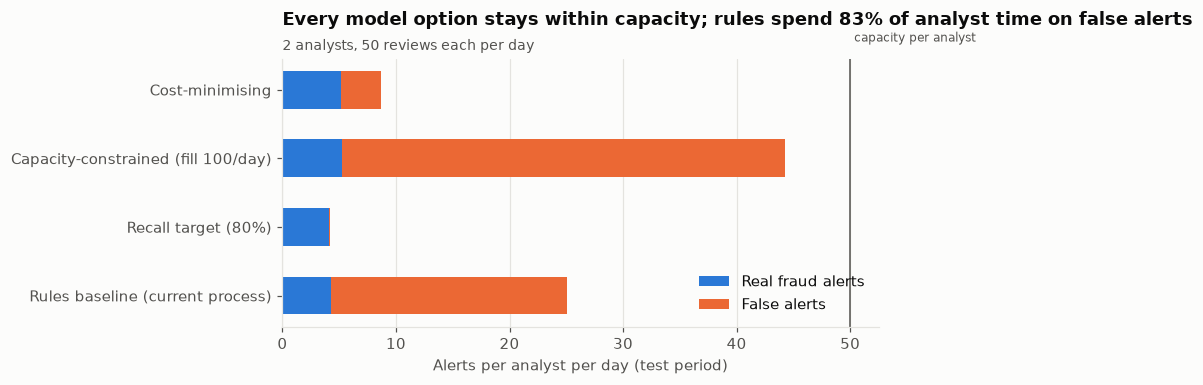

In [12]:
w = wl[wl.split == "test"].set_index("option")
fig, ax = plt.subplots(figsize=(9, 3.6))
order = list(w.index)
tp_per_analyst = w.alerts_per_analyst_per_day - w.false_alerts_per_analyst_per_day
ax.barh(order, tp_per_analyst, color=plotting.BLUE, height=0.55, label="Real fraud alerts")
ax.barh(order, w.false_alerts_per_analyst_per_day, left=tp_per_analyst, color=plotting.ORANGE, height=0.55, label="False alerts")
ax.axvline(config.REVIEWS_PER_ANALYST_PER_DAY, color=plotting.TEXT_2, lw=1)
ax.text(config.REVIEWS_PER_ANALYST_PER_DAY, -0.7, " capacity per analyst", color=plotting.TEXT_2, fontsize=8)
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("Alerts per analyst per day (test period)")
ax.legend(loc="lower right")
plotting.title(ax, f"Every model option stays within capacity; rules spend {w.loc['Rules baseline (current process)', 'false_alerts_per_analyst_per_day'] / w.loc['Rules baseline (current process)', 'alerts_per_analyst_per_day']:.0%} of analyst time on false alerts",
               f"{config.N_ANALYSTS} analysts, {config.REVIEWS_PER_ANALYST_PER_DAY} reviews each per day")
plotting.save(fig, "analyst_workload"); plt.show()

## 6. Sensitivity: how does the optimal threshold move if the assumptions are wrong?

Fraud loss and review cost are each moved by ±50%, and the cost-minimising threshold is re-optimised on validation for every combination.

In [13]:
sens = costs.sensitivity(va.is_fraud, va[MODEL], va.amt, DAYS["validation"], grid_va)
sens.to_csv(config.REPORTS / "sensitivity_analysis.csv", index=False)
piv_t = sens.pivot(index="fraud_loss_multiplier", columns="review_cost_multiplier", values="optimal_threshold")
piv_a = sens.pivot(index="fraud_loss_multiplier", columns="review_cost_multiplier", values="alerts_per_day")
piv_r = sens.pivot(index="fraud_loss_multiplier", columns="review_cost_multiplier", values="recall")
display(Markdown("**Optimal threshold** (rows: fraud-loss multiplier, columns: review-cost multiplier)")); display(piv_t)
display(Markdown("**Alerts per day at the optimum**")); display(piv_a.round(1))
display(Markdown("**Recall at the optimum**")); display(piv_r.round(3))

**Optimal threshold** (rows: fraud-loss multiplier, columns: review-cost multiplier)

review_cost_multiplier,0.5000,1.0000,1.5000
fraud_loss_multiplier,,,
0.5000,0.0084,0.0084,0.0296
1.0000,0.0042,0.0084,0.0084
1.5000,0.0031,0.0042,0.0084


**Alerts per day at the optimum**

review_cost_multiplier,0.5000,1.0000,1.5000
fraud_loss_multiplier,,,
0.5000,21.2000,21.2000,16.8000
1.0000,25.2000,21.2000,21.2000
1.5000,27.6000,25.2000,21.2000


**Recall at the optimum**

review_cost_multiplier,0.5000,1.0000,1.5000
fraud_loss_multiplier,,,
0.5000,0.9810,0.9810,0.9660
1.0000,0.9850,0.9810,0.9810
1.5000,0.9860,0.9850,0.9810


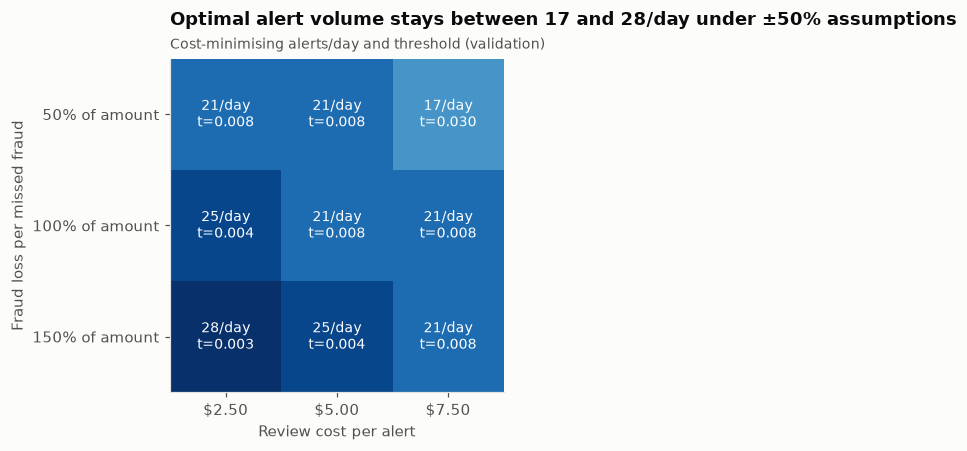

**Takeaway:** Across all nine combinations the optimal threshold ranges 0.003-0.030 and recall 97%-99%. The recommendation is robust to the cost assumptions because the score separates classes sharply.

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
im = ax.imshow(piv_a.values, cmap="Blues", vmin=0)
for (i, j), v in np.ndenumerate(piv_a.values):
    ax.text(j, i, f"{v:.0f}/day\nt={piv_t.values[i, j]:.3f}", ha="center", va="center", fontsize=9,
            color="white" if v > piv_a.values.max() * 0.6 else plotting.TEXT)
ax.set_xticks(range(3), [f"${config.REVIEW_COST * m:.2f}" for m in piv_a.columns])
ax.set_yticks(range(3), [f"{m:.0%} of amount" for m in piv_a.index])
ax.set_xlabel("Review cost per alert"); ax.set_ylabel("Fraud loss per missed fraud")
ax.grid(False)
plotting.title(ax, f"Optimal alert volume stays between {piv_a.values.min():.0f} and {piv_a.values.max():.0f}/day under ±50% assumptions",
               "Cost-minimising alerts/day and threshold (validation)")
plotting.save(fig, "sensitivity_heatmap"); plt.show()
takeaway(f"Across all nine combinations the optimal threshold ranges {piv_t.values.min():.3f}-{piv_t.values.max():.3f} and recall "
         f"{piv_r.values.min():.0%}-{piv_r.values.max():.0%}. The recommendation is robust to the cost assumptions because the score separates classes sharply.")

## 7. Model vs current rules at the same alert volume

The fairest comparison: give LightGBM **exactly as many alerts as the rules generate**, the same analyst workload, and compare what each catches. This is done on test, the unseen future period.

In [15]:
cmp_rows = []
for split_name, d in [("validation", va), ("test", te)]:
    nd = DAYS[split_name]
    r_rules = metrics.at_threshold(d.is_fraud, d["score_Rules baseline"], d.amt, 1.0, nd)
    t_same = metrics.threshold_for_alert_volume(d[MODEL].to_numpy(), r_rules["alerts"])
    r_model = metrics.at_threshold(d.is_fraud, d[MODEL], d.amt, t_same, nd)
    for name, r in [("Rules baseline", r_rules), ("LightGBM @ same alert volume", r_model)]:
        c = costs.sweep(d.is_fraud, d["score_Rules baseline"] if name == "Rules baseline" else d[MODEL], d.amt, nd, [r["threshold"]]).iloc[0]
        cmp_rows.append({"split": split_name, "approach": name, **{k: r[k] for k in ["alerts", "alerts_per_day", "TP", "FP", "FN", "precision", "recall",
                         "fraud_caught_usd", "fraud_missed_usd", "dollar_recall"]}, "total_cost_usd": c.total_cost_usd})
same_vol = pd.DataFrame(cmp_rows)
same_vol.to_csv(config.REPORTS / "model_vs_rules_same_volume.csv", index=False)
same_vol.set_index(["split", "approach"])

alerts  alerts_per_day    TP    FP   FN  precision  recall  fraud_caught_usd  fraud_missed_usd  dollar_recall  total_cost_usd
split      approach                                                                                                                                                   
validation Rules baseline                  6497         46.4071  1520  4977  387     0.2340  0.7971      963,156.6200       27,835.6500         0.9719     60,320.6500
           LightGBM @ same alert volume    6497         46.4071  1890  4607   17     0.2909  0.9911      989,751.2200        1,241.0500         0.9987     33,726.0500
test       Rules baseline                  6468         50.1395  1106  5362  252     0.1710  0.8144      717,171.2700       20,883.7900         0.9717     53,223.7900
           LightGBM @ same alert volume    6468         50.1395  1347  5121   11     0.2083  0.9919      735,927.2500        2,127.8100         0.9971     34,467.8100

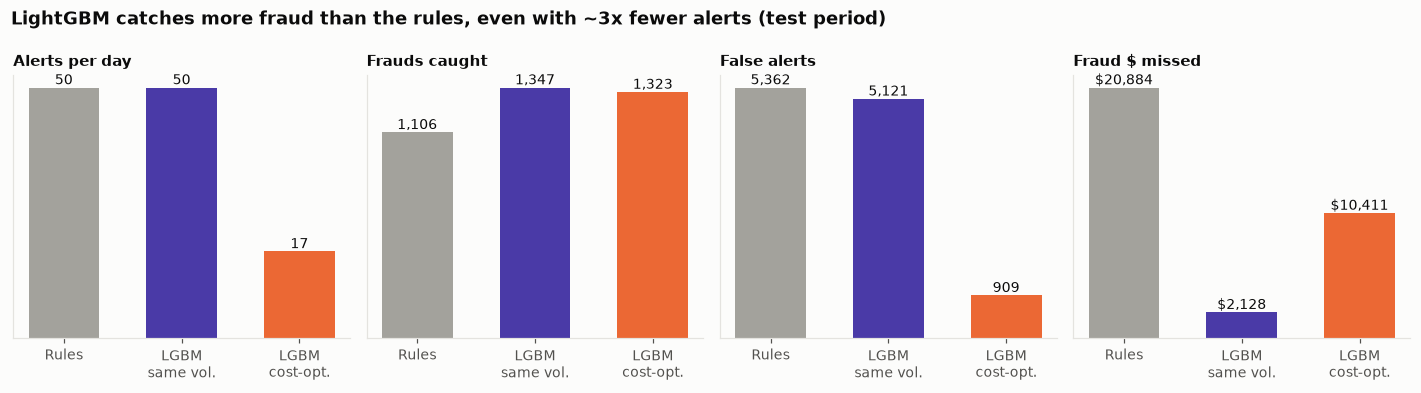

**Takeaway:** At the rules' own alert volume on test (50/day), LightGBM catches 1,347 frauds vs 1,106 (recall 99% vs 81%) and cuts missed fraud from \$20,884 to \$2,128. At its cost-optimal threshold it needs only 17.3 alerts/day (vs 50.1) to reach 97% recall, with 909 false alerts vs 5,362 for the rules.

In [16]:
sv = same_vol[same_vol.split == "test"].set_index("approach")
r, m = sv.loc["Rules baseline"], sv.loc["LightGBM @ same alert volume"]
rec_te = confirm.set_index(["option", "split"]).loc[("Cost-minimising", "test")]
bars = pd.DataFrame({
    "Rules (current)": [r.alerts_per_day, r.TP, r.FP, r.fraud_missed_usd],
    "LightGBM, same volume": [m.alerts_per_day, m.TP, m.FP, m.fraud_missed_usd],
    "LightGBM, cost-optimal": [rec_te.alerts_per_day, rec_te.TP, rec_te.FP, rec_te.fraud_missed_usd],
}, index=["Alerts per day", "Frauds caught", "False alerts", "Fraud $ missed"])
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
colors = [plotting.NEUTRAL, plotting.VIOLET, plotting.ORANGE]
for ax, (metric_name, vals) in zip(axes, bars.iterrows()):
    ax.bar(range(3), vals.values, color=colors, width=0.6)
    for i, v in enumerate(vals.values):
        ax.text(i, v, (f"${v:,.0f}" if "$" in metric_name else f"{v:,.0f}"), ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(3), ["Rules", "LGBM\nsame vol.", "LGBM\ncost-opt."], fontsize=9)
    ax.set_title(metric_name, fontsize=10, loc="left"); ax.grid(axis="x", visible=False); ax.set_yticks([])
fig.suptitle(f"LightGBM catches more fraud than the rules, even with ~{r.alerts_per_day / rec_te.alerts_per_day:.0f}x fewer alerts (test period)",
             x=0.01, ha="left", fontweight="bold")
plotting.save(fig, "model_vs_rules"); plt.show()
takeaway(f"At the rules' own alert volume on test ({r.alerts_per_day:.0f}/day), LightGBM catches {m.TP:,.0f} frauds vs {r.TP:,.0f} "
         f"(recall {m.recall:.0%} vs {r.recall:.0%}) and cuts missed fraud from \${r.fraud_missed_usd:,.0f} to \${m.fraud_missed_usd:,.0f}. "
         f"At its cost-optimal threshold it needs only {rec_te.alerts_per_day:.1f} alerts/day (vs {r.alerts_per_day:.1f}) to reach {rec_te.recall:.0%} recall, "
         f"with {rec_te.FP:,.0f} false alerts vs {r.FP:,.0f} for the rules.")

In [17]:
# Summary of the recommended operating point for the README and dashboard
rec = {
    "recommended_option": "Cost-minimising" if opt_cost.alerts_per_day <= config.DAILY_REVIEW_CAPACITY else "Capacity-constrained (fill 100/day)",
    "thresholds": thr,
    "validation_days": DAYS["validation"], "test_days": DAYS["test"],
}
(config.REPORTS / "threshold_decision.json").write_text(json.dumps(rec, indent=2))
rec

{'recommended_option': 'Cost-minimising',
 'thresholds': {'Cost-minimising': 0.008447008853411628,
  'Capacity-constrained (fill 100/day)': 0.00016928301623390284,
  'Recall target (80%)': 0.8889368437434058},
 'validation_days': 140,
 'test_days': 129}